<a href="https://colab.research.google.com/github/qiaozhou-qz/MarketingMixModelling-MMM/blob/main/MarketingMixModel_Kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Computing ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% -:--:--

Computing ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% -:--:--

                                                                                 mean        sd  eti89_lb  eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
adstock_alpha[Paid_Views]                                                       0.258     0.203     0.019      0.65     4154     2013  1.00    0.0029    0.002
adstock_alpha[Google_Impressions]                                                 0.6     0.126      0.38      0.76     2059     1615  1.00    0.0032   0.0035
adstock_alpha[Email_Impressions]                                                 0.23     0.163     0.018      0.51     2606     1861  1.00     0.003   0.0017
adstock_alpha[Facebook_Impressions]                                             0.476     0.139      0.22      0.66     2291     1683  1.00    0.0032   0.0026
adstock_alpha[Affiliate_Impressions]                                            0.272     0.213     0.016      0.69     3627     1866  1.00    0.0032   0.0022
saturation_lam[Paid_Views]                    

Output()

/tmp/ipykernel_4754/2771490713.py:95: FutureWarning: The legacy MMMPlotSuite will be removed in pymc-marketing 2.0.0. Set mmm.plot_suite = 'new' to opt in to the new namespace-based API. See the migration guide: https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_plot_suite_migration_guide.html
  mmm.plot.posterior_predictive()


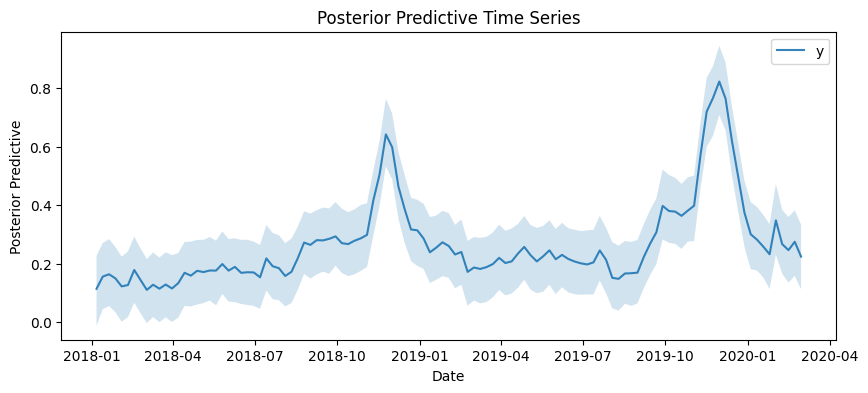

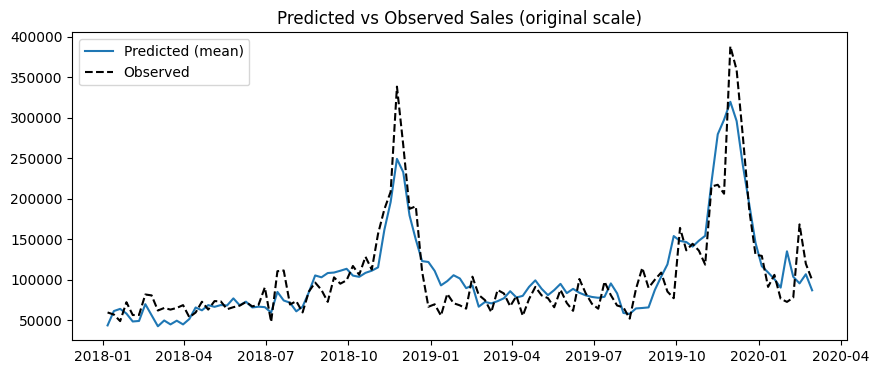

Total Sales contribution by channel (original scale):
channel
Paid_Views               1.608470e+05
Google_Impressions       4.179982e+06
Email_Impressions        6.995929e+06
Facebook_Impressions     2.608429e+06
Affiliate_Impressions    1.822317e+06
Name: channel_contribution, dtype: float64

Contribution per unit of channel activity:
  Paid_Views: total contribution = 160,847, ratio = 0.1515
  Google_Impressions: total contribution = 4,179,982, ratio = 0.0754
  Email_Impressions: total contribution = 6,995,929, ratio = 0.1590
  Facebook_Impressions: total contribution = 2,608,429, ratio = 0.1430
  Affiliate_Impressions: total contribution = 1,822,317, ratio = 2.0446


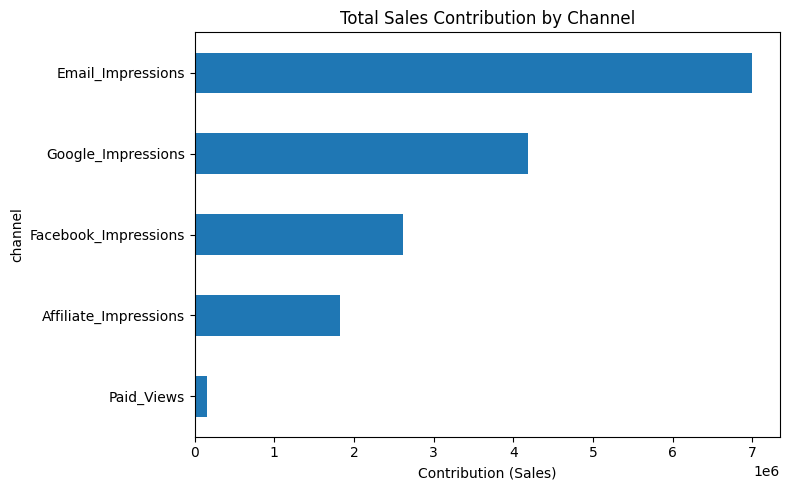

In [1]:
"""
Marketing Mix Model (MMM) — Final Working Version
===================================================
Dataset: Sample Media Spends Data (Kaggle)
https://www.kaggle.com/datasets/yugagrawal95/sample-media-spends-data

Environment: Google Colab
pymc-marketing version: 1.0.0 (pymc 6.0.1)

This is the consolidated, working version of every code block used to
build and evaluate this model. Run each "# %%" block as its own cell.
"""

# %% [1] Install packages
# %% !pip install pymc-marketing pandas matplotlib seaborn arviz -q

# %% [2] Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation

# %% [3] Load data
DATA_PATH = "sample_media_spend_data.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df.head())
print(df.columns.tolist())

# %% [4] Inspect divisions and date format
print("Unique divisions:", df["Division"].unique())
print("Number of divisions:", df["Division"].nunique())
print("Sample Calendar_Week values:")
print(df["Calendar_Week"].head(10))

# %% [5] Filter to a single division
chosen_division = df["Division"].unique()[0]
df = df[df["Division"] == chosen_division].copy()
print(f"Filtered to division: {chosen_division}, {len(df)} rows")

# %% [6] Convert date column
df["Calendar_Week"] = pd.to_datetime(df["Calendar_Week"])
df = df.sort_values("Calendar_Week").reset_index(drop=True)

# %% [7] Define columns
date_col = "Calendar_Week"
target_col = "Sales"
channel_cols = [
    "Paid_Views",
    "Google_Impressions",
    "Email_Impressions",
    "Facebook_Impressions",
    "Affiliate_Impressions",
]

# %% [8] EDA plot
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(df[date_col], df[target_col])
axes[0].set_title("Target (Sales) over time")
for c in channel_cols:
    axes[1].plot(df[date_col], df[c], label=c)
axes[1].legend()
axes[1].set_title("Channel activity over time")
plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120)
plt.show()


# %% [9] Build the model
mmm = MMM(
    date_column=date_col,
    channel_columns=channel_cols,
    control_columns=None,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    target_column=target_col,  # required: y's name ("Sales") must match this
)

X = df[[date_col] + channel_cols]
y = df[target_col]

# %% [10] Fit the model (takes a few minutes)
mmm.fit(X, y, target_accept=0.9, chains=4, random_seed=42)

# %% [11] Diagnostics — check convergence (r_hat should be ~1.0)
summary = az.summary(mmm.idata)
print(summary)

# %% [12] Posterior predictive check (in-sample fit quality)
mmm.sample_posterior_predictive(X, extend_idata=True)
mmm.plot.posterior_predictive()
plt.show()

# %% [13] Posterior predictive in original (dollar) scale, vs. observed
# target_scale comes from posterior_predictive_constant_data — this
# version scales by max-abs value rather than using a sklearn transformer.
target_scale = mmm.idata.posterior_predictive_constant_data["target_scale"].values

pp = mmm.idata.posterior_predictive["y"]
pp_mean = pp.mean(dim=["chain", "draw"]).values
pp_mean_original = pp_mean * target_scale

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df[date_col], pp_mean_original, label="Predicted (mean)", color="tab:blue")
ax.plot(df[date_col], df[target_col], label="Observed", color="black", linestyle="--")
ax.legend()
ax.set_title("Predicted vs Observed Sales (original scale)")
plt.savefig("predicted_vs_observed.png", dpi=120)
plt.show()

# %% [14] Channel contribution & efficiency ratio (original scale)
# channel_contribution already lives in mmm.idata.posterior with dims
# (chain, draw, date, channel) — average over chain/draw, unscale, then sum.
channel_contrib = mmm.idata.posterior["channel_contribution"]
channel_contrib_mean = channel_contrib.mean(dim=["chain", "draw"])
channel_contrib_original = channel_contrib_mean * target_scale

total_contribution_by_channel = channel_contrib_original.sum(dim="date")

print("Total Sales contribution by channel (original scale):")
print(total_contribution_by_channel.to_pandas())

print("\nContribution per unit of channel activity:")
for c in channel_cols:
    total_contrib = total_contribution_by_channel.sel(channel=c).item()
    total_activity = df[c].sum()
    ratio = total_contrib / total_activity if total_activity > 0 else np.nan
    print(f"  {c}: total contribution = {total_contrib:,.0f}, ratio = {ratio:.4f}")

# %% [15] Plot channel contribution share
contrib_series = total_contribution_by_channel.to_pandas().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
contrib_series.plot(kind="barh", ax=ax)
ax.set_title("Total Sales Contribution by Channel")
ax.set_xlabel("Contribution (Sales)")
plt.tight_layout()
plt.savefig("channel_contribution.png", dpi=120)
plt.show()

# %% [16] NOTE on limitations
# This dataset reports impressions, not spend, so contribution-per-unit
# ratios are NOT directly comparable across channels (an affiliate
# impression is a structurally different, rarer/higher-intent event than
# a Facebook or Google impression). Affiliate's outlier ratio (~2.0 vs.
# 0.07-0.16 for other channels) should be read as a unit-comparability
# artifact, not a true efficiency signal. A cost-per-channel dataset would
# be needed to compute genuine ROAS.

# %% [17] Budget optimization (optional — API varies by version)
# from pymc_marketing.mmm.budget_optimizer import BudgetOptimizer
# optimizer = BudgetOptimizer(mmm_model=mmm, num_periods=4)
# total_budget = df[channel_cols].sum(axis=1).mean() * 4
# allocation, response = optimizer.allocate_budget(total_budget=total_budget)
# print(allocation)
